In [3]:
"""
train_benchmark.py — CCTV-SPCrime detection benchmark (solves Tables IV and V).

Trains and evaluates variants of the YOLO family (YOLOv8n, YOLO11n, YOLO26n) UNDER THE SAME
SPLIT and with FIXED HYPERPARAMETERS (reproducibility), and generates:
  - results_models.csv  -> comparison between models (Table IV of the paper)
  - results_perclass.csv-> results by class of the adopted model (Table V)

HYPERPARAMETERS (they document the reproducibility section of the paper):
  imgsz=640, epochs=100, batch=16, optimizer=SGD, lr0=0.01, lrf=0.01,
  momentum=0.937, weight_decay=0.0005, patience=20, seed=0.
  Reported inference confidence threshold: 0.37 (max F1 on validation).

DEPENDENCIES
    pip install ultralytics
Use
    python train_benchmark.py --data dataset/data.yaml \
        --models yolov8n.pt yolo11n.pt yolo26n.pt \
        --primary yolo26n.pt --epochs 100 --batch 16 --seed 0
--------------------------------------------------------------------------------
"""

!pip install -q ultralytics
!pip install -q pydrive2

import argparse
import csv
import sys
from pathlib import Path
import os
from ultralytics import YOLO
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)




In [ ]:
HP = dict(
    imgsz=640,
    optimizer="SGD",
    lr0=0.01,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    patience=20
    )

CONF_REPORT = 0.37  # reported confidence threshold (max F1 on validation)

BASE_DIR = r"scripts/"

DATASETS_DIR = os.path.join(BASE_DIR, 'dataset')
DATA_YAML = os.path.join(DATASETS_DIR, 'dataset.yaml')

MODELS = ["yolov8n.pt", "yolo11n.pt", "yolo26n.pt"]
PRIMARY = "yolo26n.pt"
EPOCHS = 100
BATCH = 32
SEED = 0
PROJECT = os.path.join(BASE_DIR, 'runs_benchmark')
RESULTS_MODELS = os.path.join(BASE_DIR, 'results_models.csv')
RESULTS_PER_CLASS = os.path.join(BASE_DIR, 'results_perclass.csv')

In [6]:
model_rows, perclass_rows = [], []

for weights in MODELS:
    tag = Path(weights).stem
    print(f"\n=== {tag}: train ({EPOCHS} epoch) ===")
    model = YOLO(weights)

    model.train(
        data=DATA_YAML,
        epochs=EPOCHS,
        batch=BATCH,
        seed=SEED,
        project=PROJECT,
        device = 0,
        name=f"{tag}_train",
        exist_ok=True,
        verbose=False,
        **HP,
    )

    print(f"=== {tag}: evaluation on the TEST set ===")
    metrics = model.val(
        data=DATA_YAML,
        split="test",
        conf=CONF_REPORT,
        project=PROJECT,
        name=f"{tag}_test",
        exist_ok=True,
        verbose=False,
    )

    b = metrics.box
    p = float(b.mp)
    r = float(b.mr)
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0

    model_rows.append({
        "model": tag,
        "mAP50": round(float(b.map50), 2),
        "mAP50_95": round(float(b.map), 2),
        "precision": round(p, 2),
        "recall": round(r, 2),
        "F1": round(f1, 2)
    })

    if Path(weights).stem == Path(PRIMARY).stem:
        names = metrics.names if hasattr(metrics, "names") else model.names
        maps = list(b.maps)
        try:
            p_c, r_c = list(b.p), list(b.r)
            f1_c = []
            for pi, ri in zip(p_c, r_c):
                if pi is None or ri is None or (pi + ri) == 0:
                    f1_c.append("")
                else:
                    f1_c.append(round(2 * pi * ri / (pi + ri), 2))
        except Exception:
            p_c, r_c = [None] * len(maps), [None] * len(maps)

        for i, ap50_95 in enumerate(maps):
            cname = names[i] if isinstance(names, (list, dict)) else str(i)
            if isinstance(names, dict):
                cname = names.get(i, str(i))

            perclass_rows.append({
                "class_id": i,
                "class": cname,
                "precision": round(p_c[i], 2) if i < len(p_c) and p_c[i] is not None else "",
                "recall": round(r_c[i], 2) if i < len(r_c) and r_c[i] is not None else "",
                "F1": f1_c[i] if i < len(f1_c) else "",
                "mAP50_95": round(float(ap50_95), 2),
            })

with open(RESULTS_MODELS, "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=["model", "mAP50", "mAP50_95", "precision", "recall", "F1"])
    w.writeheader()
    w.writerows(model_rows)

with open(RESULTS_PER_CLASS, "w", newline="", encoding="utf-8") as f:
    w = csv.DictWriter(f, fieldnames=["class_id", "class", "precision", "recall", "F1", "mAP50_95"])
    w.writeheader()
    w.writerows(perclass_rows)


=== yolov8n: train (100 epoch) ===
Ultralytics 8.4.73 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/salomopena/spcrime/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_train, nbs=64, nms=False, opset=None, o

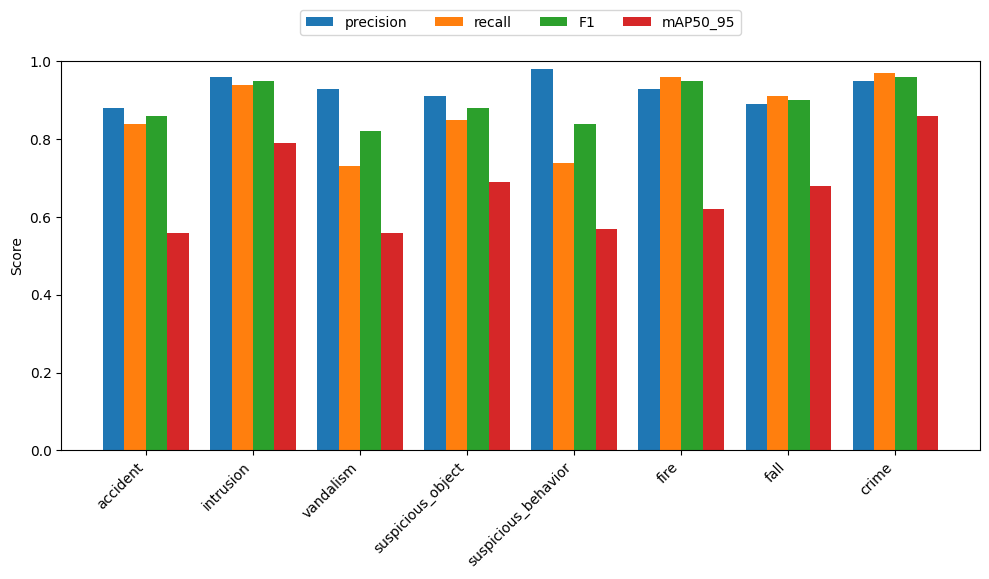

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your results
#data = pd.read_csv(RESULTS_PER_CLASS)
data = pd.read_csv(RESULTS_PER_CLASS)

df = data.copy()
metrics = ["precision", "recall", "F1", "mAP50_95"]
x = np.arange(len(df))
width = 0.2

fig, ax = plt.subplots(figsize = (10,6))

for i, m in enumerate(metrics):
    ax.bar(
        x + (i - 1.5) * width,
        df[m],
        width,
        label = m
    )

ax.set_xticks(x)
ax.set_xticklabels(df['class'], rotation = 45, ha="right")
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
#ax.set_title("Metrics per class")
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=len(metrics),
)
plt.tight_layout()
plt.show()



In [25]:
macro_precision = data["precision"].mean()
macro_recall    = data["recall"].mean()
macro_f1        = data["F1"].mean()
macro_map       = data["mAP50_95"].mean()

print(f"precision {macro_precision:.2} recall {macro_recall:.2} F1{macro_f1:.2} mAP50:95 {macro_map:.2}")

precision 0.93 recall 0.87 F10.9 mAP50:95 0.67


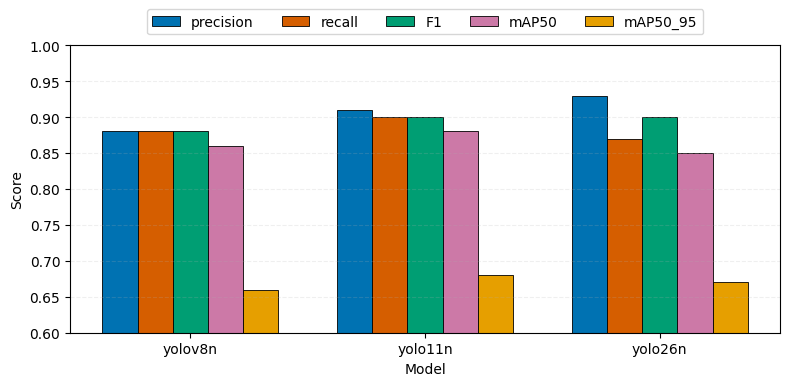

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Read CSV
df = pd.read_csv(RESULTS_MODELS) 

# 2. Organizing data
models = df["model"].tolist()
metrics = ["precision", "recall", "F1", "mAP50", "mAP50_95"]

# Paleta Okabe–Ito 
colors = {
    "precision":  "#0072B2",  # bule
    "recall":     "#D55E00",  # orenge red
    "F1":         "#009E73",  # green
    "mAP50":      "#CC79A7",  # wine
    "mAP50_95":   "#E69F00",  # yellow/orange
}

x = np.arange(len(models))
width = 0.15

fig, ax = plt.subplots(figsize=(8, 4))

for i, metric in enumerate(metrics):
    values = df[metric].values
    ax.bar(
        x + (i - 2) * width,
        values,
        width,
        label=metric,
        color=colors[metric],
        edgecolor="black",
        linewidth=0.6,
    )

# 3. Adjustes 
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.6, 1.0)
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.grid(axis="y", linestyle="--", alpha=0.2)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=len(metrics),
)
plt.tight_layout()
plt.savefig("metrics_models_okabe_ito.png", dpi=300) 
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Read CSV
df = pd.read_csv("scripts/results_perclass.csv") 